### <span style="color:#50C878; font-weight:bold;">Load in Data</span>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Load the dataset
data = pd.read_csv('Car_Kh24.csv')

df = pd.DataFrame(data)

# df.info()
# data.isnull().sum()
# df.nunique()

### <span style="color:#50C878; font-weight:bold;">Remove Duplicate Date</span>


In [2]:
# find duplicates
duplicates = df[df.duplicated()]

# count duplicates
print(f"Number of duplicate rows: {len(duplicates)}")

#drop duplicates
df = df.drop_duplicates()

Number of duplicate rows: 6


### <span style="color:#50C878; font-weight:bold;">Drop Unused Columns</span>

In [3]:
df.columns = df.columns.str.strip()

columns_to_drop = ['Ad ID', 'Category', 'Locations', 'Link', 'Title', 'Year Used']

df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

df.columns

Index(['Car Makes', 'Car Model', 'Year', 'Tax Type', 'Condition', 'Body Type',
       'Fuel', 'Transmission', 'Color', 'Price'],
      dtype='object')

### <span style="color:#50C878; font-weight:bold;">Remove Rows with NULL in Specific Columns</span>

In [4]:
df = df.dropna(subset=['Car Makes', 'Year', 'Car Model'])

df.head()

,Car Makes,Car Model,Year,Tax Type,Condition,Body Type,Fuel,Transmission,Color,Price
0,Toyota,Highlander,2003.0,Plate Number,Used,Sports,Petrol,Auto,Black,"$14,000"
1,Lexus,NX,2015.0,Tax Paper,Used,NaN,Petrol,Auto,White,"$39,500"
2,Toyota,Land Cruiser,2022.0,Plate Number,Used,SUV,Petrol,Auto,Black,"$155,000"
3,Lexus,RX330,2004.0,Plate Number,Used,SUV,Petrol,Auto,Gray,"$20,500"
4,Lexus,NX,2015.0,Tax Paper,Used,NaN,Petrol,Auto,White,"$51,999"


### <span style="color:#50C878; font-weight:bold;">Imputation (Body Type, Fuel, Transmission and Color)</span>

In [5]:
df.isnull().sum()

Car Makes          0
Car Model          0
Year               0
Tax Type           0
Condition          0
Body Type       3621
Fuel            2129
Transmission    1454
Color            187
Price              0
dtype: int64

In [6]:
# Fill NaN in by the most frequent 'Column' of the same 'Car Model'
df['Body Type']    = df.groupby('Car Model')['Body Type'].transform(lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else "Unknown"))
df['Fuel']         = df.groupby('Car Model')['Fuel'].transform(lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else "Unknown"))
df['Transmission'] = df.groupby('Car Model')['Transmission'].transform(lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else "Unknown"))

# Replace Color NaN to 'Unknown'
df['Color'] = df['Color'].fillna('Unknown')

df.isnull().sum()

# # Count the number of 'Unknown' values in each column
# unknown_count = (df == 'Unknown').sum()

# print(unknown_count)

Car Makes       0
Car Model       0
Year            0
Tax Type        0
Condition       0
Body Type       0
Fuel            0
Transmission    0
Color           0
Price           0
dtype: int64

### <span style="color:#50C878; font-weight:bold;">Listing Data</span>

In [7]:
# # Strip trailing spaces from the column names
# df.columns = df.columns.str.strip()

# # List unique Car Brand
# Brand = df['Car Makes'].unique().tolist()

# print("Unique Car Makes:")
# for i, brand in enumerate(Brand, start=1):
#     print(f"{i}. {brand}")

# # List unique Car Model
# Model = df['Car Model'].unique().tolist()

# print("Unique Car Model:")
# for i, model in enumerate(Model, start=1):
#     print(f"{i}. {model}")

### <span style="color:#50C878; font-weight:bold;">Convert Categorical Variables to Numeric</span>

In [8]:
# Encode categorical columns
le = LabelEncoder()

# Columns to encode
categorical_cols = ['Car Makes', 'Car Model', 'Tax Type', 'Condition', 'Body Type', 'Fuel', 'Transmission', 'Color']

# Apply label encoding to categorical columns
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,Car Makes,Car Model,Year,Tax Type,Condition,Body Type,Fuel,Transmission,Color,Price
0,59,249,2003.0,0,1,7,4,0,1,"$14,000"
1,38,333,2015.0,1,1,5,4,0,13,"$39,500"
2,59,285,2022.0,0,1,5,4,0,1,"$155,000"
3,38,371,2004.0,0,1,5,4,0,5,"$20,500"
4,38,333,2015.0,1,1,5,4,0,13,"$51,999"


### <span style="color:#50C878; font-weight:bold;">Convert Price from String to Float</span>

In [9]:
# Remove the dollar sign and commas, then convert to float
df['Price'] = df['Price'].replace({'\$': '', ',': ''}, regex=True).astype(float)

df.head()

<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
C:\Users\PCN\AppData\Local\Temp\ipykernel_14772\122613265.py:2: SyntaxWarning: invalid escape sequence '\$'
  df['Price'] = df['Price'].replace({'\$': '', ',': ''}, regex=True).astype(float)


,Car Makes,Car Model,Year,Tax Type,Condition,Body Type,Fuel,Transmission,Color,Price
0,59,249,2003.0,0,1,7,4,0,1,14000.0
1,38,333,2015.0,1,1,5,4,0,13,39500.0
2,59,285,2022.0,0,1,5,4,0,1,155000.0
3,38,371,2004.0,0,1,5,4,0,5,20500.0
4,38,333,2015.0,1,1,5,4,0,13,51999.0


### <span style="color:#50C878; font-weight:bold;">Correlation Analysis of Car Features and Price</span>

              Car Makes  Car Model      Year  Tax Type  Condition  Body Type  \
Car Makes      1.000000  -0.088372 -0.269522  0.053746  -0.025861   0.046493   
Car Model     -0.088372   1.000000  0.055622  0.036903  -0.021820  -0.165296   
Year          -0.269522   0.055622  1.000000  0.324748  -0.304855  -0.103538   
Tax Type       0.053746   0.036903  0.324748  1.000000  -0.590441  -0.068616   
Condition     -0.025861  -0.021820 -0.304855 -0.590441   1.000000   0.004467   
Body Type      0.046493  -0.165296 -0.103538 -0.068616   0.004467   1.000000   
Fuel           0.132114  -0.147942 -0.186872 -0.052622   0.043883   0.224867   
Transmission  -0.104179   0.071019 -0.156422 -0.058988   0.079079  -0.144052   
Color          0.016306   0.059179  0.093348  0.042014  -0.055251  -0.042463   
Price         -0.177749  -0.052857  0.543123  0.156529  -0.144945  -0.032711   

                  Fuel  Transmission     Color     Price  
Car Makes     0.132114     -0.104179  0.016306 -0.177749  
C

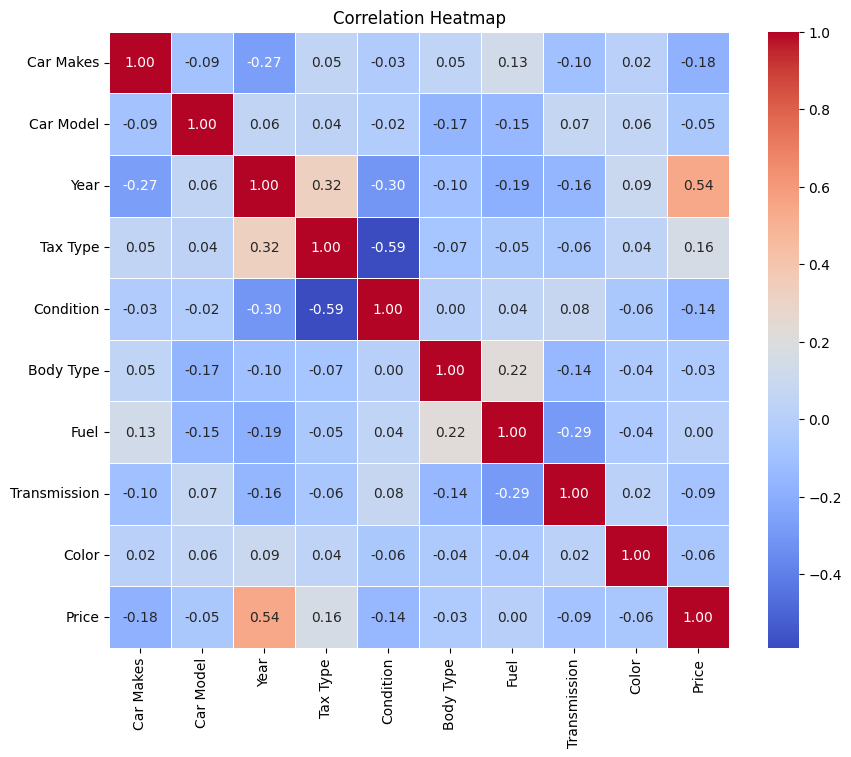

In [10]:
# Select only numeric columns for correlation matrix calculation
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Calculate the correlation matrix for numeric columns
correlation_matrix = df[numeric_columns].corr()

# Print the correlation matrix
print(correlation_matrix)

# Generate a heatmap for the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


### <span style="color:#50C878; font-weight:bold;">Summary of Key Findings:</span>
- **Year** is positively correlated with **Price**, as newer cars generally cost more.
- **Tax Type** has a strong negative correlation with **Condition**, which may indicate that different tax types (like "Tax Paper") are associated with different car conditions.
- **Fuel Type** and **Body Type** have a mild positive correlation, possibly indicating that certain types of cars (e.g., SUVs) tend to use certain fuels.
- **Transmission Type** has a weak negative correlation with **Price**, suggesting that automatic transmissions are more common in higher-priced vehicles, but the correlation isn't very strong.

### <span style="color:#50C878; font-weight:bold;">Next Steps:</span>
1. **Feature Selection**: Based on the correlation matrix, you may decide which features to keep for model building. For example, **Fuel** and **Color** have very weak correlations with **Price**, so you might consider excluding them from your model.
2. **Data Preprocessing**: Since some correlations are weak, you could explore additional feature engineering or transformations that might better capture the relationships between the variables.
3. **Modeling**: Using the most correlated features (like **Year**, **Tax Type**, and **Body Type**), you can start building regression models or other machine learning algorithms to predict **Price**.


In [11]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score


# Step 2: Preprocess the dataset
# Separate features and target
X = df.drop(columns=['Price'])  # Replace 'price' with your car price column name
y = df['Price']

# Identify categorical and numeric columns
categorical_features = X.select_dtypes(include=['object']).columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns

# Create preprocessing pipelines
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Step 3: Create a Ridge Regression pipeline
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('ridge', Ridge())
])

# Step 4: Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Train Ridge Regression with cross-validation
param_grid = {'ridge__alpha': [0.1, 1.0, 10.0, 100.0]}  # Grid of alpha values
ridge_cv = GridSearchCV(ridge_pipeline, param_grid, cv=5, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train, y_train)

# Best model
best_model = ridge_cv.best_estimator_
print(f"Best Alpha: {ridge_cv.best_params_['ridge__alpha']}")

# Step 6: Evaluate the model
y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

Best Alpha: 10.0
Mean Squared Error: 1029298687.8623658
R^2 Score: 0.29585279218240146


In [12]:
# Example: New car data for prediction
new_car_data = pd.DataFrame({
    'Car Make': ['Toyota'],
    'Car Model': ['Camry'],
    'Year': [2020],
    'Condition': ['Used'],
    'Fuel': ['Petrol'],
    'Posted': ['10-Jun-23'],
    'Tax Type': [0],
    'Body Type': [5],
    'Transmission': [1],
    'Color': ['White']
    # Add all other relevant features as in your original dataset
})

# Predict the car price using the trained model
predicted_price = best_model.predict(new_car_data)
print(f"Predicted Price: {predicted_price[0]:.2f}")

ValueError: columns are missing: {'Car Makes'}

In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# Step 3: Create a Random Forest Regression pipeline with n_jobs=-1 for parallelization
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('rf', RandomForestRegressor(n_jobs=-1, random_state=42))  # Use all cores for faster training
])

# Step 4: Split the dataset (This part remains the same)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Train Random Forest Regressor with GridSearchCV
param_grid_rf = {
    'rf__n_estimators': [100, 150, 200],  # Reduce the range of n_estimators for faster results
    'rf__max_depth': [None, 10, 15],      # Reduce max_depth for faster tree training
    'rf__min_samples_split': [2, 5],      # Reduced values for faster computation
    'rf__min_samples_leaf': [1, 2]        # Reduced values for faster computation
}

# Perform Grid Search with cross-validation (Reduced cv=3 for faster results)
rf_cv = GridSearchCV(rf_pipeline, param_grid_rf, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
rf_cv.fit(X_train, y_train)

# Best model
best_rf_model = rf_cv.best_estimator_
print(f"Best Parameters: {rf_cv.best_params_}")

# Step 6: Evaluate the model
y_pred_rf = best_rf_model.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Mean Squared Error: {mse_rf}")
print(f"Random Forest R^2 Score: {r2_rf}")


Best Parameters: {'rf__max_depth': 10, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 5, 'rf__n_estimators': 200}
Random Forest Mean Squared Error: 1014407776.502638
Random Forest R^2 Score: 0.3060397221566227


In [45]:
# Assuming the necessary columns are already encoded and that 'Car Make' and 'Car Model' are numerical (after LabelEncoder).
# For simplicity, we will manually input the required features for a new Mercedes CLA45 car.

# Example: New car data for prediction
new_car_data = pd.DataFrame({
    'Car Make': ['Mercedes-Benz'],
    'Car Model': ['C300'],
    'Year': [2015],
    'Condition': ['Used'],
    'Fuel': ['Petrol'],
    'Posted': ['10-Jun-23'],
    'Tax Type': [0],
    'Body Type': [5],
    'Transmission': [1],
    'Color': ['White']
    # Add all other relevant features as in your original dataset
})

# Predict the car price using the trained Random Forest Regressor model
predicted_price = best_rf_model.predict(new_car_data)
print(f"Predicted Price for Mercedes S350: ${predicted_price[0]:.2f}")


Predicted Price for Mercedes S350: $49707.46
